In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system import BatHeadDirectionSystem
from grid_cells.plot_tools import angular_error, smooth_ts
import os
from concurrent.futures import ThreadPoolExecutor

PLOTS_DIR = os.path.join("..", "plots")

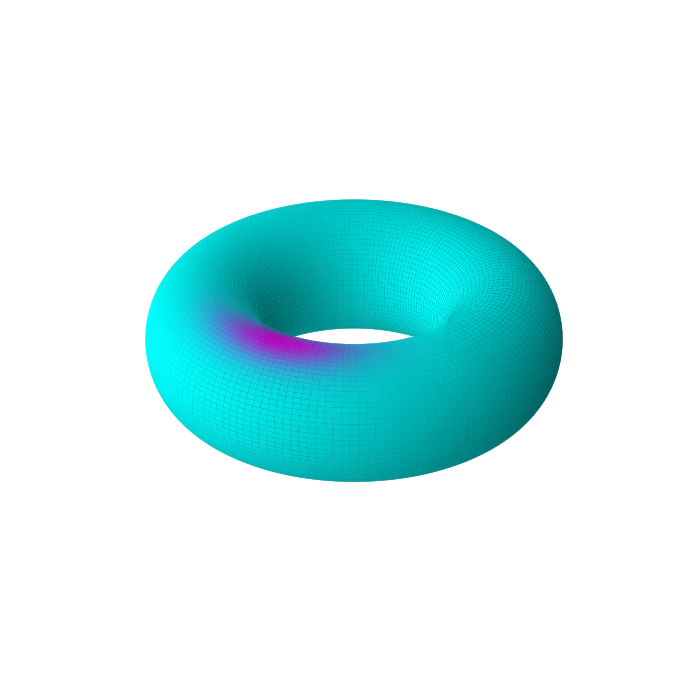

In [2]:
# Torus surface with a periodic activity bump
u = np.linspace(0, 2 * np.pi, 160)
v = np.linspace(0, 2 * np.pi, 80)
u, v = np.meshgrid(u, v)

R, r = 10, 4
x = (R + r * np.cos(v)) * np.cos(u)
y = (R + r * np.cos(v)) * np.sin(u)
z = r * np.sin(v)

# Periodic angular distance for a localized bump
u0, v0 = 3 * np.pi / 2, np.pi / 2
du = np.angle(np.exp(1j * (u - u0)))
dv = np.angle(np.exp(1j * (v - v0)))

activity = np.exp(-(du**2 + dv**2) / (2 * 0.35**2))

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    x,
    y,
    z,
    facecolors=plt.cm.cool(activity),
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=True,
)


ax.set_box_aspect((1, 1, 0.3))
ax.set_axis_off()
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "torus_bump.png"))